This code demonstrates classification using embeddings with logits and MLP. To run it, follow these steps:

1. Run the first two sections: Initialization and Data Preparation, to obtain and preprocess the data.
2. Depending on your requirements, run the corresponding sections.

Note that we provide the embeddings from OpenAI stored in CSV, the corresponding code to return OpenAI embedding is provided in Appendix.

# Initialization

In [1]:
import pandas as pd
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import time, datetime
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split, cross_val_score
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset
import pickle
from joblib import dump, load
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import fisher_exact
import copy
import random
import scipy.stats as stats
import ast
import copy

In [2]:
import matplotlib.font_manager as fm
import seaborn as sns

_font_size = 38

In [3]:
class Net_test(nn.Module):
    def __init__(self, hidden_size=128, hidden_layer_num=1, dropout_rate=0.5, rate=2, DIM=256):
        super(Net_test, self).__init__()
        self.rate = rate
        self.hidden_layer_num = hidden_layer_num
        self.hidden_size = hidden_size
        self.fc1 = nn.Linear(DIM*2, self.hidden_size)
        self.dropout = nn.Dropout(dropout_rate) 
        num_max = int(self.hidden_size/self.rate)           
        self.fc_hidden = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.hidden_size, self.get_hidden_size()),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ) for _ in range(min(self.hidden_layer_num - 1, num_max-1))
        ])
        self.fc2 = nn.Linear(self.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
   
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        for fc in self.fc_hidden:
            x = fc(x)
        x = self.fc2(x)
        return self.sigmoid(x)
    
    def get_hidden_size(self):
        self.hidden_size = int(self.hidden_size/self.rate)
        return self.hidden_size

In [4]:
def loss_computation(net_, testloader, loss_history_test):
    criterion = nn.BCELoss()
    with torch.no_grad():
        running_loss_test = 0
        for data in testloader:
            inputs, labels = data  
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                labels = labels.cuda()
            outputs = net_(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))      
            running_loss_test += loss.item()
        loss_history_test.append(running_loss_test / len(testloader))
    return loss_history_test
 

        
def acc_computation(net_, X_test, y_test):
    with torch.no_grad(): 
        outputs = net_(X_test.cuda())
        predicted = torch.round(outputs.cuda())
        accuracy_ = (predicted.squeeze().cuda() == y_test.cuda()).sum().item() / y_test.cuda().size(0)
    return accuracy_
        
    
        
def prediction_w_NN(X_train, y_train, X_test, y_test, DIM=256, proportion=0.2, lr=0.01, batch_size=10, EPOCH=1000, early_stopping_rounds=None, tol=None, hidden_size=128, hidden_layer_num=1, dropout_rate=0.5, weight_decay = 0.01, rate=2, fin=False, optim_name='sgd', loss_history_val=None):    
    net = Net_test(hidden_size=hidden_size, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, rate=rate, DIM=DIM)
    if torch.cuda.is_available():
        net = net.cuda()
    
    criterion = nn.BCELoss()
    if optim_name == 'adam':
        optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)
    
    trainset = TensorDataset(X_train, y_train)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    testset = TensorDataset(X_test, y_test)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)
    
    loss_history_train = []
    loss_history_test = []
    acc_history_train = []
    acc_history_test = []
    best_loss = float('inf')  
    early_stopping_counter = 0 
    print(f'Start Training Neural Network_hidden_size_{proportion}:hidden_size_{hidden_size}_hidden_layer_num:{hidden_layer_num}_dropout_rate:{dropout_rate}_weight_decay:{weight_decay}')
    
    start_time = time.time()
    epoch_1 = 0
    for epoch in range(EPOCH):
        epoch_1 = epoch
        acc_samples = 0
        running_loss = 0.0
        net.train()
        for index, data in enumerate(trainloader, 0):
            inputs, labels = data  
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                labels = labels.cuda()
            optimizer.zero_grad()
            outputs = net(inputs)  # Slowest
            predicted = torch.round(outputs)  
            acc_samples += (predicted.squeeze() == labels).sum().item()
            
            loss = criterion(outputs, labels.unsqueeze(1))      
            loss.backward()     
            optimizer.step()                 
            running_loss += loss.item()
        if epoch % (EPOCH // 10) == 0:
            eta = (time.time() - start_time) / (epoch + 1) * (EPOCH - epoch - 1)
            print('[%d] loss: %.3f, eta: %s' % (epoch + 1, running_loss / (index + 1), str(datetime.timedelta(seconds=eta))))
        loss_history_train.append(running_loss / len(trainloader))  
        acc_history_train.append(acc_samples/y_train.size(0))
    
        loss_history_test = loss_computation(net, testloader, loss_history_test)
        net.eval()
        acc_history_test.append(acc_computation(net, X_test=X_test, y_test=y_test))
        #print(acc_computation(net, X_test=X_test, y_test=y_test))
   
        if early_stopping_rounds is not None:  
            if tol is None:
                tol = np.finfo(np.float32).eps
            if best_loss - loss_history_val[-1] > tol: 
                best_loss = loss_history_val[-1]
                early_stopping_counter = 0
                if fin and epoch >= 10:
                    torch.save(net.state_dict(), f'Best_models_for_hyperparameter_search_proportion_{proportion}/NN_{hidden_size}_hidden_layer_num_{hidden_layer_num}_dropout_rate_{dropout_rate}_weight_decay_{weight_decay}_rate_{rate}_fin_{fin}.pth')
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= early_stopping_rounds:
                    print("Best val_loss at epochs:", epoch-early_stopping_rounds+1)
                    break
        
    if early_stopping_rounds is None:
        early_stopping_rounds = 0
    accuracy_train = acc_history_train[epoch_1-early_stopping_rounds]
    accuracy_test = acc_history_test[epoch_1-early_stopping_rounds]
    
    print('train_accuracy:', accuracy_train)
    print('test_accuracy:', accuracy_test)
    print('Finished Training')
    print('Total period: ',time.time()-start_time)
    
    return net, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test

# Data Preparation

In [5]:
# Generate and save the embeddings needed for the following codes

def embed_generate_save(DIM=256):
    print('get data from csv')
    df = pd.read_csv(f'stored_embeddings_significant/selected_pairs_df_005_{DIM}.csv')
    embed_1 = torch.tensor(np.array([eval(s) for s in df['embedding_1']])).to(torch.float32)
    embed_2 = torch.tensor(np.array([eval(s) for s in df['embedding_2']])).to(torch.float32)
    
    directory_path = 'stored_embeddings_significant/train_val_test_split/'
    embed_1_path = f'{directory_path}embed_1_{DIM}.pt'
    embed_2_path = f'{directory_path}embed_2_{DIM}.pt'
    torch.save(embed_1, embed_1_path)
    torch.save(embed_2, embed_2_path)


embed_generate_save(DIM=256)
embed_generate_save(DIM=3072)

get data from csv
get data from csv


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [6]:
directory_name = 'stored_embeddings_significant'
if not os.path.exists(directory_name):
    os.mkdir(directory_name)
print(f"Directory '{directory_name}' is ready.")

Directory 'stored_embeddings_significant' is ready.


In [9]:
DIM = 256
print('get data from csv')
file_path = 'stored_embeddings_significant/selected_pairs_df_005_' + str(DIM) + '.csv'
df_embedding_256 = pd.read_csv(file_path)
df_embedding_256['test_id'] = df_embedding_256.groupby(['clickability_test_id', 'eyecatcher_id']).ngroup() + 1

DIM = 3072
print('get data from csv')
file_path = 'stored_embeddings_significant/selected_pairs_df_005_' + str(DIM) + '.csv'
df_embedding_3072 = pd.read_csv(file_path)
df_embedding_3072['test_id'] = df_embedding_3072.groupby(['clickability_test_id', 'eyecatcher_id']).ngroup() + 1

get data from csv
get data from csv


In [12]:
# Define directory path and file names for saving individual components with variables included
def embed_get(DIM, directory_path='stored_embeddings_significant/train_val_test_split/'):
    embed_1_path = f'{directory_path}embed_1_{DIM}.pt'
    embed_2_path = f'{directory_path}embed_2_{DIM}.pt'
    embed_1 = torch.load(embed_1_path)
    embed_2 = torch.load(embed_2_path)
    return embed_1, embed_2

In [13]:
def dataset_extraction(df, test_size, DIM=3072, rs = 42):
    random_state = rs
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=df['test_id']))
    train_df = df.iloc[train_idx]
    test_df_original = df.iloc[test_idx]

    train_headlines = set(train_df['headline_1'].tolist() + train_df['headline_2'].tolist())
    test_df = test_df_original[~test_df_original['headline_1'].isin(train_headlines)]
    test_df = test_df[~test_df['headline_2'].isin(train_headlines)]
    print(f'Filtered Num Compared to the Begining_test_size_{test_size}', (len(test_df_original)-len(test_df)))
    print(f'Remaining samples of the test set:', len(test_df))
    print(f'Filter Ratio Compared to the Begining_test_size_{test_size}', (len(test_df_original)-len(test_df))/len(test_df_original))

    embed_1, embed_2 = embed_get(DIM=DIM)
    X_train = torch.cat([embed_1[train_df.index], embed_2[train_df.index]], dim=1)
    y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1
    X_test = torch.cat([embed_1[test_df.index], embed_2[test_df.index]], dim=1)
    y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1
    
    return X_train, y_train, X_test, y_test

# OpenAI Embeddings for classification

## Cosine Similarity

In [12]:
DIM=3072

df = copy.deepcopy(df_embedding_3072)
embed_1, embed_2 = embed_get(DIM=DIM)

### Total Similarity

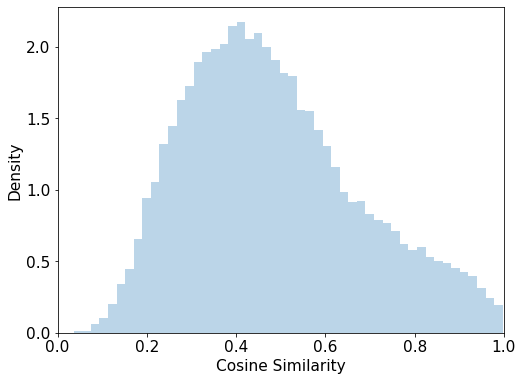

In [13]:
similarities = [cosine_similarity(embed_1[i].reshape(1, -1), embed_2[i].reshape(1, -1))[0][0] for i in range(embed_1.shape[0])]
similarities = np.array(similarities)

plt.figure(figsize=(8, 6))
plt.grid(None)

plt.hist(similarities, bins = 50, density = 1, alpha=0.3)
plt.grid(None)
plt.xlabel('Cosine Similarity', fontsize=10/0.65)
plt.ylabel('Density', fontsize=10/0.65)
plt.tick_params(labelsize=10/0.65)
plt.xlim((0, 1))

plt.savefig(f'total_similarity.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)

plt.show()


### Prediction Similarity

In [28]:
random_state = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=random_state)
train_idx, test_idx = next(gss.split(df, groups=df[['test_id']]))

In [29]:
train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]
train_headlines = set(train_df['headline_1'].tolist() + train_df['headline_2'].tolist())
test_df = test_df[~test_df['headline_1'].isin(train_headlines)]
test_df = test_df[~test_df['headline_2'].isin(train_headlines)]

In [30]:
X_train = torch.cat([embed_1[train_df.index], embed_2[train_df.index]], dim=1)
y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1

X_test = torch.cat([embed_1[test_df.index], embed_2[test_df.index]], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1

In [31]:
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
print('Simple Linear Model Performance + gpt embedding')
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)

accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)


Simple Linear Model Performance + word2vec
Accuracy on training data: 0.8613791202299846
95% CI: [ 0.8571289085487394 , 0.8656293319112299 ]
Accuracy on test data: 0.8225681686327596
95% CI: [ 0.815205156401805 , 0.8299311808637142 ]


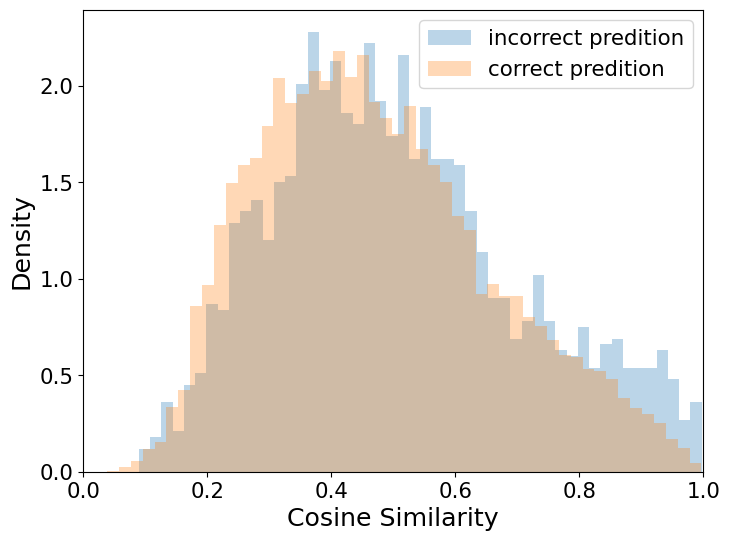

In [33]:
plt.figure(figsize=(8, 6))
plt.grid(None)

similarities = [cosine_similarity(X_test[:, 0:DIM][i].reshape(1, -1), X_test[:, DIM:][i].reshape(1, -1))[0][0] for i in range(X_test[:, DIM:].shape[0])]
similarities = np.array(similarities)
test_result = np.array(np.equal(y_test, clf.predict(X_test)))

indices_ = np.where(test_result == 0)[0]
plt.hist(similarities[indices_], label = 'incorrect predition', bins = 50, alpha = 0.3, density = 1, edgecolor='none')
indices_ = np.where(test_result == 1)[0]
plt.hist(similarities[indices_], label = 'correct predition', bins = 50, alpha = 0.3, density = 1, edgecolor='none')

plt.xlabel('Cosine Similarity',  fontsize=10/0.55)
plt.ylabel('Density',  fontsize=10/0.55)
plt.legend(fontsize= 10/0.65)
plt.tick_params(labelsize=10/0.65)
plt.grid(None)
plt.xlim((0, 1))

plt.savefig(f'cosine_similarity_comparison.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)

plt.show()

## Logits Regression

### DIM=256

In [34]:
DIM = 256
df = copy.deepcopy(df_embedding_256)

#### 20% test data

In [61]:
X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=0.2, DIM=DIM)
# regression
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
print('Simple Linear Model Performance + gpt embedding')
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)


accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)

Filtered Num Compared to the Begining_test_size_0.2 2188
Remaining samples of the test set: 5624
Filter Ratio Compared to the Begining_test_size_0.2 0.28008192524321557
Simple Linear Model Performance + gpt embedding
Accuracy on training data: 0.7854909717348306
Accuracy on test data: 0.7731152204836416


#### Different Proportion

In [62]:
#due to the large randomness with only 5%, 10% test data, we truncate the display
test_size_array = np.arange(1, 20)*0.05
accuracy_train_list = []
accuracy_test_list = []

In [63]:
for test_size in test_size_array:
    print(f'data_preparation_test_size_{test_size}')
    X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=test_size, DIM=DIM, rs = 40)
    clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
    print('Simple Logistic Model Performance + gpt embedding')
    
    accur = clf.score(X_train, y_train)
    total = len(X_train)                              
    print('Accuracy on training data:', accur)
    accuracy_train_list.append(accur)

    accur = clf.score(X_test, y_test)
    total = len(X_test)                      
    print('Accuracy on test data:', accur)
    accuracy_test_list.append(accur)

data_preparation_test_size_0.05
Filtered Num Compared to the Begining_test_size_0.05 651
Remaining samples of the test set: 1279
Filter Ratio Compared to the Begining_test_size_0.05 0.3373056994818653
Simple Logistic Model Performance + gpt embedding
Accuracy on training data: 0.7847050607069948
Accuracy on test data: 0.7756059421422987
data_preparation_test_size_0.1
Filtered Num Compared to the Begining_test_size_0.1 1240
Remaining samples of the test set: 2605
Filter Ratio Compared to the Begining_test_size_0.1 0.32249674902470743
Simple Logistic Model Performance + gpt embedding
Accuracy on training data: 0.7862260357375471
Accuracy on test data: 0.7696737044145874
data_preparation_test_size_0.15000000000000002
Filtered Num Compared to the Begining_test_size_0.15000000000000002 1819
Remaining samples of the test set: 3908
Filter Ratio Compared to the Begining_test_size_0.15000000000000002 0.3176182992840929
Simple Logistic Model Performance + gpt embedding
Accuracy on training data:

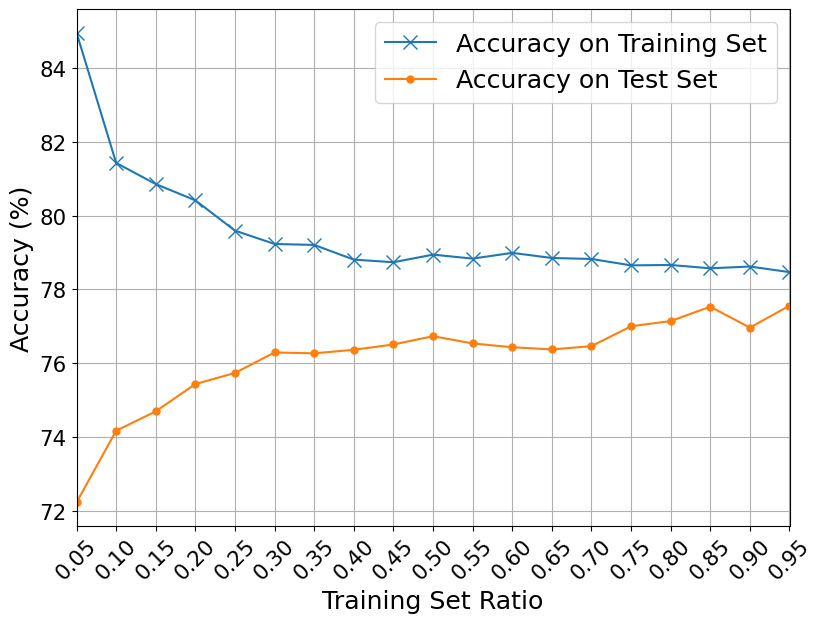

In [64]:
x = 1 - np.arange(1, 20)/20  
labels =  np.around(np.arange(0.05, 1, 0.05), 2)

plt.figure(figsize=(8, 6))
plt.grid(True)
plt.plot(x, 100*np.array(accuracy_train_list), label='Accuracy on Training Set', marker='x', markersize=10)
plt.legend()

plt.plot(x, 100*np.array(accuracy_test_list), label='Accuracy on Test Set', marker='.', markersize=10)
plt.legend()

plt.xlabel('Training Set Ratio',  fontsize=10/0.55)
plt.ylabel('Accuracy (%)',  fontsize=10/0.55)
plt.legend(fontsize= 10/0.55)
plt.tight_layout()
plt.xticks(x, labels=['{:.2f}'.format(label) for label in x], rotation=45)
plt.tick_params(labelsize=10/0.65)
plt.xlim((0.05, 0.95))

plt.savefig(f'results_proportion_ratio_regression_256.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)

plt.show()



### DIM=3072

In [8]:
DIM = 3072
df = copy.deepcopy(df_embedding_3072)

#### 20% test data

In [14]:
X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=0.2, DIM=DIM)
# regression
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
print('Simple Linear Model Performance + gpt embedding')
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)

accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)

Filtered Num Compared to the Begining_test_size_0.2 2188
Remaining samples of the test set: 5624
Filter Ratio Compared to the Begining_test_size_0.2 0.28008192524321557
Simple Linear Model Performance + gpt embedding
Accuracy on training data: 0.8616729407260895
Accuracy on test data: 0.8248577524893315


In [26]:
df

,Unnamed: 0,clickability_test_id,eyecatcher_id,headline_1,headline_2,higher_CTR,CTR_1,CTR_2,Size_1,Size_2,p_value,embedding_1,embedding_2,test_id
0,3,5143605e220cb80002000076,5332b5101fae79f09f00020c,"SCIENCE FACT: Gay Science, Like Straight Scien...","Here's The Science, Here's The Gay. Open Your ...",2,0.007744,0.013271,4132.0,4069.0,1.666367e-02,"[0.043684832751750946, -0.009005947969853878, ...","[0.03786730766296387, -0.026843197643756866, -...",1
1,4,5143605e220cb80002000076,5332b5101fae79f09f00020c,"SCIENCE FACT: Gay Science, Like Straight Scien...",If You Know Anyone Who Is Afraid Of Gay People...,2,0.007744,0.028881,4132.0,4155.0,2.265775e-13,"[0.043684832751750946, -0.009005947969853878, ...","[-0.00554250692948699, -0.016612781211733818, ...",1
2,5,5143605e220cb80002000076,5332b5101fae79f09f00020c,"Hey Dude. If You Have An Older Brother, There'...",If You Know Anyone Who Is Afraid Of Gay People...,2,0.010049,0.028881,4080.0,4155.0,4.156051e-10,"[-0.009783176705241203, -0.014572054147720337,...","[-0.00554250692948699, -0.016612781211733818, ...",1
3,8,5143605e220cb80002000076,5332b5101fae79f09f00020c,"Here's The Science, Here's The Gay. Open Your ...",If You Know Anyone Who Is Afraid Of Gay People...,2,0.013271,0.028881,4069.0,4155.0,7.409125e-07,"[0.03769439086318016, -0.0266555268317461, -0....","[-0.005530505906790495, -0.016624677926301956,...",1
4,9,5143605e220cb80002000076,5332b5101fae79f09f00020c,I've Got Some News For You. Being Gay Is Genet...,If You Know Anyone Who Is Afraid Of Gay People...,2,0.009615,0.028881,4160.0,4155.0,7.622063e-11,"[-0.00564286345615983, -0.01770932413637638, -...","[-0.00554250692948699, -0.016612781211733818, ...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39153,140642,55414789313638001c520000,55412d5a643265000c0f0300,There's a big taboo in Egypt that it's not ok ...,An Egyptian taboo says it's not ok to say your...,1,0.017318,0.004900,2021.0,2041.0,1.351113e-04,"[-0.016268666833639145, -0.05848972871899605, ...","[-0.04825235903263092, -0.054329413920640945, ...",11740
39154,140650,55414789313638001c520000,55412d5a643265000c0f0300,Moms aren't very visible in Egypt. Their sons ...,An Egyptian taboo says it's not ok to say your...,1,0.013752,0.004900,2036.0,2041.0,3.202930e-03,"[0.0027324454858899117, 0.001968991244211793, ...","[-0.04825235903263092, -0.054329413920640945, ...",11740
39155,140652,55414789313638001c520000,55412d5a643265000c0f0300,There's a big taboo in Egypt that it's not ok ...,A cultural taboo in Egypt actually has people ...,1,0.017318,0.009886,2021.0,2023.0,4.254584e-02,"[-0.016268666833639145, -0.05848972871899605, ...","[-0.027094608172774315, -0.013983887620270252,...",11740
39156,140653,55414789313638001c520000,55412d5a643265000c0f0300,An Egyptian taboo says it's not ok to say your...,There's a big taboo in Egypt that it's not oka...,2,0.004900,0.014160,2041.0,2048.0,3.233821e-03,"[-0.048262059688568115, -0.05434033274650574, ...","[-0.018842285498976707, -0.045045413076877594,...",11740


#### Test if LoRA is significantly better than embedding 

In [21]:
from scipy import stats

y_test_pred = np.array(clf.predict(X_test))
y_test_acc = (y_test_pred == np.array(y_test))
y_test_pred_lora = np.load('xxx.npy')
y_test_acc_lora = (y_test_pred_lora == np.array(y_test))

t_stat, p_value = stats.ttest_rel(y_test_acc_lora, y_test_acc)
print(f'T-statistic: {t_stat}, p-value: {p_value}')

if p_value < 0.05:
    print("There is significant difference in accuracy.")
else:
    print("There is significant difference in accuracy.")

array([1., 1., 1., ..., 0., 1., 0.], dtype=float32)

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

y_test_pred = np.array(clf.predict(X_test))
y_test_acc = (y_test_pred == np.array(y_test))
y_test_pred_lora = np.load('xxx.npy')
y_test_acc_lora = (y_test_pred_lora == np.array(y_test))

# McNemar's Test matrix
b = np.sum((y_test_acc == True) & (y_test_acc_lora == False))
c = np.sum((y_test_acc == False) & (y_test_acc_lora == True))

# McNemar's Test
result = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
print(f'Statistic: {result.statistic}, p-value: {result.pvalue}')

if result.pvalue < 0.05:
    print("There is a significant difference between the two classifiers.")
else:
    print("There is no significant difference between the two classifiers.")

#### Different Proportion

In [70]:
df = copy.deepcopy(df_embedding_3072)

In [71]:
test_size_array = np.arange(1, 20)*0.05
accuracy_train_list = []
accuracy_test_list = []

In [72]:
for test_size in test_size_array:
    print(f'data_preparation_test_size_{test_size}')
    X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=test_size, rs = 40)
    clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
    print('Simple Logistic Model Performance + gpt embedding')
    
    accur = clf.score(X_train, y_train)
    total = len(X_train)                         
    print('Accuracy on training data:', accur)
    accuracy_train_list.append(accur)
    
    accur = clf.score(X_test, y_test)
    total = len(X_test)        
    print('Accuracy on test data:', accur)
    accuracy_test_list.append(accur)
    

data_preparation_test_size_0.05
Filtered Num Compared to the Begining_test_size_0.05 651
Remaining samples of the test set: 1279
Filter Ratio Compared to the Begining_test_size_0.05 0.3373056994818653
Simple Logistic Model Performance + gpt embedding
Accuracy on training data: 0.8594606210379284
Accuracy on test data: 0.8217357310398749
data_preparation_test_size_0.1
Filtered Num Compared to the Begining_test_size_0.1 1240
Remaining samples of the test set: 2605
Filter Ratio Compared to the Begining_test_size_0.1 0.32249674902470743
Simple Logistic Model Performance + gpt embedding
Accuracy on training data: 0.8606462209384645
Accuracy on test data: 0.8145873320537428
data_preparation_test_size_0.15000000000000002
Filtered Num Compared to the Begining_test_size_0.15000000000000002 1819
Remaining samples of the test set: 3908
Filter Ratio Compared to the Begining_test_size_0.15000000000000002 0.3176182992840929
Simple Logistic Model Performance + gpt embedding
Accuracy on training data:

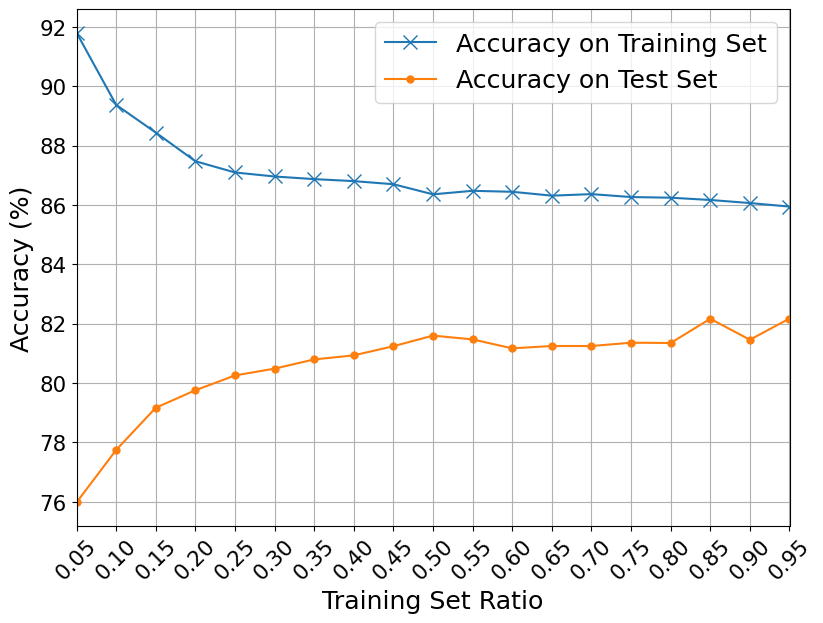

In [73]:
x = 1 - np.arange(1, 20)/20  
labels =  np.around(np.arange(0.05, 1, 0.05), 2)

plt.figure(figsize=(8, 6))
plt.grid(True)
plt.plot(x, 100*np.array(accuracy_train_list), label='Accuracy on Training Set', marker='x', markersize=10)
plt.legend()

plt.plot(x, 100*np.array(accuracy_test_list), label='Accuracy on Test Set', marker='.', markersize=10)
plt.legend()

plt.xlabel('Training Set Ratio',  fontsize=10/0.55)
plt.ylabel('Accuracy (%)',  fontsize=10/0.55)
plt.legend(fontsize= 10/0.55)
plt.tight_layout()
plt.xticks(x, labels=['{:.2f}'.format(label) for label in x], rotation=45)
plt.tick_params(labelsize=10/0.65)
plt.xlim((0.05, 0.95))

plt.savefig(f'results_proportion_ratio_regression_3072.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)
plt.show()

## MLP
A class of neural networks

### DIM=256

In [19]:
DIM = 256

df = copy.deepcopy(df_embedding_256)
X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=0.2, DIM=DIM)

Filtered Num Compared to the Begining_test_size_0.2 2188
Remaining samples of the test set: 5624
Filter Ratio Compared to the Begining_test_size_0.2 0.28008192524321557


In [20]:
lr=0.01
batch_size=10
EPOCH=1000

In [27]:
weight_decay = 0.0001
hidden_size=256
hidden_layer_num=1
dropout_rate=0.5
rate=2

best_epochs = 74  # # The optimal epochs are 32

In [30]:
torch.manual_seed(0)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)

Start Training Neural Network_hidden_size_0.2:hidden_size_256_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.691, eta: 0:08:16.522351
[8] loss: 0.488, eta: 0:07:29.321672
[15] loss: 0.465, eta: 0:06:35.653500
[22] loss: 0.453, eta: 0:05:47.035356
[29] loss: 0.443, eta: 0:04:59.387751
[36] loss: 0.430, eta: 0:04:12.797109
[43] loss: 0.416, eta: 0:03:26.904265
[50] loss: 0.402, eta: 0:02:40.994731
[57] loss: 0.388, eta: 0:01:53.801846
[64] loss: 0.370, eta: 0:01:06.810996
[71] loss: 0.355, eta: 0:00:20.014073
train_accuracy: 0.8554201493013462
test_accuracy: 0.7763157894736842
Finished Training
Total period:  493.91844272613525


In [31]:
torch.manual_seed(1)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)

Start Training Neural Network_hidden_size_0.2:hidden_size_256_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.690, eta: 0:07:55.337264
[8] loss: 0.488, eta: 0:07:28.121650
[15] loss: 0.466, eta: 0:06:41.591541
[22] loss: 0.454, eta: 0:05:54.657901
[29] loss: 0.444, eta: 0:05:06.880302
[36] loss: 0.431, eta: 0:04:19.280156
[43] loss: 0.418, eta: 0:03:31.555240
[50] loss: 0.405, eta: 0:02:43.727864
[57] loss: 0.391, eta: 0:01:55.924865
[64] loss: 0.376, eta: 0:01:08.024238
[71] loss: 0.359, eta: 0:00:20.385414
train_accuracy: 0.8505072417533338
test_accuracy: 0.7772048364153628
Finished Training
Total period:  503.16105794906616


In [32]:
torch.manual_seed(2)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)

# If you load the model, you can run the following code:

# net_fin = Net_test(hidden_size=hidden_size, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, rate=rate)
# net_fin.load_state_dict(torch.load(f'Best_models_for_hyperparameter_search/NN_{256}_hidden_layer_num_{1}_dropout_rate_{0.5}_weight_decay_{0.0001}_rate_{2}_fin_{True}.pth'))  # load the NN weights
# net_fin.eval()
# with torch.no_grad():     
#     outputs = net_fin(X_train)
#     predicted = torch.round(outputs) 
#     acc_train_fin_ = (predicted.squeeze() == y_train).sum().item()/len(y_train)
#     outputs = net_fin(X_test)
#     predicted = torch.round(outputs)
#     acc_test_fin_ = (predicted.squeeze() == y_test).sum().item()/len(y_test)    
# print('acc_train_fin:', acc_train_fin_)
# print('acc_test_fin:', acc_test_fin_)
# # NN
# total = len(X_test)
# print('Accuracy on test data:', acc_test_fin_)
# print('95% CI:', '[', CI_lower_test, ',', CI_upper_test,']')

Start Training Neural Network_hidden_size_0.2:hidden_size_256_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.691, eta: 0:07:55.931542
[8] loss: 0.490, eta: 0:07:20.641244
[15] loss: 0.464, eta: 0:06:33.524167
[22] loss: 0.453, eta: 0:05:47.080094
[29] loss: 0.442, eta: 0:05:00.596098
[36] loss: 0.430, eta: 0:04:13.997902
[43] loss: 0.417, eta: 0:03:27.250982
[50] loss: 0.402, eta: 0:02:40.461370
[57] loss: 0.386, eta: 0:01:53.678766
[64] loss: 0.371, eta: 0:01:07.085268
[71] loss: 0.357, eta: 0:00:20.172601
train_accuracy: 0.8517833216359344
test_accuracy: 0.7750711237553343
Finished Training
Total period:  498.4345738887787


### DIM=3072

In [33]:
DIM = 3072

df = copy.deepcopy(df_embedding_3072)
X_train, y_train, X_test, y_test = dataset_extraction(df=df, test_size=0.2, DIM=DIM)

Filtered Num Compared to the Begining_test_size_0.2 2188
Remaining samples of the test set: 5624
Filter Ratio Compared to the Begining_test_size_0.2 0.28008192524321557


In [34]:
lr=0.01
batch_size=10
EPOCH=1000

In [35]:
# Best Hyperparameters

hidden_layer_num = 1
dropout_rate = 0.5
hidden_size = 2048
weight_decay = 1e-4
rate = 4

best_epochs = 32  # # The optimal epochs are 32

In [36]:
torch.manual_seed(0)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)

Start Training Neural Network_hidden_size_0.2:hidden_size_2048_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.691, eta: 0:04:29.108206
[4] loss: 0.578, eta: 0:04:05.323182
[7] loss: 0.433, eta: 0:03:38.927414
[10] loss: 0.395, eta: 0:03:12.647665
[13] loss: 0.375, eta: 0:02:46.402832
[16] loss: 0.362, eta: 0:02:20.062062
[19] loss: 0.351, eta: 0:01:53.777505
[22] loss: 0.342, eta: 0:01:27.586301
[25] loss: 0.334, eta: 0:01:01.410702
[28] loss: 0.326, eta: 0:00:35.163844
[31] loss: 0.319, eta: 0:00:08.805189
train_accuracy: 0.8634913545587953
test_accuracy: 0.8209459459459459
Finished Training
Total period:  282.3209946155548


In [37]:
torch.manual_seed(1)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)

Start Training Neural Network_hidden_size_0.2:hidden_size_2048_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.691, eta: 0:04:25.437921
[4] loss: 0.579, eta: 0:04:07.289719
[7] loss: 0.433, eta: 0:03:41.645674
[10] loss: 0.395, eta: 0:03:15.518246
[13] loss: 0.374, eta: 0:02:48.977880
[16] loss: 0.362, eta: 0:02:22.213314
[19] loss: 0.350, eta: 0:01:55.404519
[22] loss: 0.342, eta: 0:01:29.185016
[25] loss: 0.334, eta: 0:01:02.529469
[28] loss: 0.326, eta: 0:00:35.752358
[31] loss: 0.320, eta: 0:00:08.939299
train_accuracy: 0.8640974925030307
test_accuracy: 0.8250355618776671
Finished Training
Total period:  286.4734456539154


In [38]:
torch.manual_seed(2)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)
# torch.save(net.state_dict(), f'Best_models_for_hyperparameter_search/NN_embedding_3072_{hidden_size}_hidden_layer_num_{hidden_layer_num}_dropout_rate_{dropout_rate}_weight_decay_{weight_decay}_rate_{rate}_fin_{True}.pth')

# net_fin = Net_test(hidden_size=hidden_size, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, rate=rate)
# net_fin.load_state_dict(torch.load(f'Best_models_for_hyperparameter_search/NN_{256}_hidden_layer_num_{1}_dropout_rate_{0.5}_weight_decay_{0.0001}_rate_{2}_fin_{True}.pth'))  # load the NN weights

Start Training Neural Network_hidden_size_0.2:hidden_size_2048_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.691, eta: 0:04:27.741511
[4] loss: 0.575, eta: 0:04:07.615602
[7] loss: 0.432, eta: 0:03:41.931782
[10] loss: 0.395, eta: 0:03:15.606495
[13] loss: 0.375, eta: 0:02:49.033077
[16] loss: 0.361, eta: 0:02:22.347703
[19] loss: 0.351, eta: 0:01:55.717157
[22] loss: 0.342, eta: 0:01:28.982843
[25] loss: 0.334, eta: 0:01:02.399317
[28] loss: 0.326, eta: 0:00:35.706244
[31] loss: 0.319, eta: 0:00:08.934343
train_accuracy: 0.8629171186116251
test_accuracy: 0.8218349928876245
Finished Training
Total period:  286.38952589035034


## Use Word2vec Embeddings

In [139]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

In [140]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/yezikun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [151]:
def text_to_vector(text, model):
    np.random.seed(42)
    random.seed(42)
    words = word_tokenize(text.lower())
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if not word_vectors:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)


### DIM=256

#### Logits Model

In [142]:
DIM=256
df = copy.deepcopy(df_embedding_256)

In [155]:
texts = list(df['headline_1'])+list(df['headline_2'])
tokenized_texts = [word_tokenize(text.lower()) for text in texts]
model_Word2Vec = Word2Vec(tokenized_texts, vector_size=DIM, window=5, min_count=1, workers=4)

print('getting word2vec for headline_1')
df['word2vec_1'] = df['headline_1'].apply(lambda x: text_to_vector(x, model_Word2Vec))
print('getting word2vec for headline_2')
df['word2vec_2'] = df['headline_2'].apply(lambda x: text_to_vector(x, model_Word2Vec))

getting word2vec for headline_1
getting word2vec for headline_2


In [156]:
random_state = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
train_idx, test_idx = next(gss.split(df, groups=df['test_id']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

train_headlines = set(train_df['headline_1'].tolist() + train_df['headline_2'].tolist())
test_df = test_df[~test_df['headline_1'].isin(train_headlines)]
test_df = test_df[~test_df['headline_2'].isin(train_headlines)]


X_train = torch.cat([torch.tensor(np.array(train_df['word2vec_1'].tolist())).to(torch.float32), 
                     torch.tensor(np.array(train_df['word2vec_2'].tolist())).to(torch.float32)], dim=1)
y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1

X_test = torch.cat([torch.tensor(np.array(test_df['word2vec_1'].tolist())).to(torch.float32), 
                    torch.tensor(np.array(test_df['word2vec_2'].tolist())).to(torch.float32)], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1

In [157]:
clf = LogisticRegression(random_state=0, max_iter = 1000).fit(X_train, y_train)
print('Simple Linear Model Performance + word2vec')
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)

accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)


Simple Linear Model Performance + word2vec
Accuracy on training data: 0.7661290322580645
Accuracy on test data: 0.6403901414677277


#### MLP

In [158]:
lr=0.01
batch_size=10
EPOCH=1000

hidden_layer_num = 1
dropout_rate = 0.5
hidden_size = 256
weight_decay = 1e-4
rate = 2

best_epochs = 74  # original: 25 (Now change it to  74, which is the same as the epochs of GPT embedding's)

In [144]:
# best epochs = 74
torch.manual_seed(0)
net, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, DIM=DIM, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True)


Start Training Neural Network_hidden_size_0.2:hidden_size_256_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.693, eta: 0:00:42.580282
[8] loss: 0.625, eta: 0:02:30.321190
[15] loss: 0.588, eta: 0:02:24.018638
[22] loss: 0.560, eta: 0:02:09.768510
[29] loss: 0.533, eta: 0:01:51.848453
[36] loss: 0.514, eta: 0:01:34.510913
[43] loss: 0.500, eta: 0:01:17.210597
[50] loss: 0.472, eta: 0:00:59.652526
[57] loss: 0.454, eta: 0:00:42.367953
[64] loss: 0.430, eta: 0:00:24.934785
[71] loss: 0.406, eta: 0:00:07.484159
train_accuracy: 0.827116935483871
test_accuracy: 0.640528293545535
Finished Training
Total period:  186.84300065040588


In [146]:
total = len(X_test)
print('Accuracy on test data:', accuracy_test)

Accuracy on test data: 0.640528293545535


### DIM=3072

#### Logits

In [159]:
DIM = 3072
df = copy.deepcopy(df_embedding_3072)

In [160]:
texts = list(df['headline_1'])+list(df['headline_2'])
tokenized_texts = [word_tokenize(text.lower()) for text in texts]
model_Word2Vec = Word2Vec(tokenized_texts, vector_size=DIM, window=5, min_count=1, workers=4)

print('getting word2vec for headline_1')
df['word2vec_1'] = df['headline_1'].apply(lambda x: text_to_vector(x, model_Word2Vec))
print('getting word2vec for headline_2')
df['word2vec_2'] = df['headline_2'].apply(lambda x: text_to_vector(x, model_Word2Vec))


getting word2vec for headline_1
getting word2vec for headline_2


In [161]:
# Create training and testing datasets
random_state = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
train_idx, test_idx = next(gss.split(df, groups=df['test_id']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

train_headlines = set(train_df['headline_1'].tolist() + train_df['headline_2'].tolist())
test_df = test_df[~test_df['headline_1'].isin(train_headlines)]
test_df = test_df[~test_df['headline_2'].isin(train_headlines)]


X_train = torch.cat([torch.tensor(np.array(train_df['word2vec_1'].tolist())).to(torch.float32), 
                     torch.tensor(np.array(train_df['word2vec_2'].tolist())).to(torch.float32)], dim=1)
y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1

X_test = torch.cat([torch.tensor(np.array(test_df['word2vec_1'].tolist())).to(torch.float32), 
                    torch.tensor(np.array(test_df['word2vec_2'].tolist())).to(torch.float32)], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1

In [163]:
# train a simple linear model
clf = LogisticRegression(random_state=0, max_iter = 1000).fit(X_train, y_train)
print('Simple Linear Model Performance + word2vec')
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)
accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)


Simple Linear Model Performance + word2vec
Accuracy on training data: 0.75
Accuracy on test data: 0.6430426613616269


#### MLP

In [164]:
dim = 3072
lr=0.01
batch_size=10
EPOCH=1000

hidden_layer_num = 1
dropout_rate = 0.5
hidden_size = 2048
weight_decay = 1e-4
rate = 4

best_epochs = 25  # It is different from the epochs we set for the model weith the GPT embeddings

In [165]:
# epochs=25
torch.manual_seed(0)
net_fin, loss_history_train, loss_history_test, acc_history_train, acc_history_test, accuracy_train, accuracy_test = prediction_w_NN(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=best_epochs, early_stopping_rounds=None, tol=0.0001, weight_decay=weight_decay, rate=rate, fin=True, DIM=dim)

Start Training Neural Network_hidden_size_0.2:hidden_size_2048_hidden_layer_num:1_dropout_rate:0.5_weight_decay:0.0001
[1] loss: 0.692, eta: 0:02:42.396698
[3] loss: 0.679, eta: 0:06:12.082663
[5] loss: 0.662, eta: 0:06:19.114285
[7] loss: 0.642, eta: 0:05:54.095378
[9] loss: 0.621, eta: 0:05:18.990825
[11] loss: 0.606, eta: 0:04:43.565666
[13] loss: 0.595, eta: 0:04:03.866727
[15] loss: 0.585, eta: 0:03:25.510826
[17] loss: 0.573, eta: 0:02:44.588407
[19] loss: 0.569, eta: 0:02:04.039501
[21] loss: 0.565, eta: 0:01:23.113255
[23] loss: 0.554, eta: 0:00:41.634582
[25] loss: 0.555, eta: 0:00:00
train_accuracy: 0.7066532258064516
test_accuracy: 0.6388704686118479
Finished Training
Total period:  539.1518201828003


In [166]:
total = len(X_test)
print('Accuracy on test data:', accuracy_test)

Accuracy on test data: 0.6388704686118479


# Additional Experiments

## Time Shift

In [167]:
def filter_groups(group):
    # Return the group if it contains more than one unique headline, otherwise return None
    return group if len(group['headline'].unique()) > 1 else None

def find_headline_pairs_with_numbers(group):
    pairs = []
    sorted_group = group.sort_values('CTR', ascending=False).reset_index()
    for i in range(len(sorted_group) - 1):
        for j in range(i + 1, len(sorted_group)):
            headline_1 = sorted_group.iloc[i]
            headline_2 = sorted_group.iloc[j]
            # Compare the CTR values and assign 1 if the first headline's CTR is higher, else 2
            higher_ctr = 1 if headline_1['CTR'] > headline_2['CTR'] else 2
            clicks = [headline_1['clicks'], headline_2['clicks']]
            non_clicks = [headline_1['impressions'] - headline_1['clicks'], headline_2['impressions'] - headline_2['clicks']]
            contingency_table = [clicks, non_clicks]
            # Calculate the odds ratio and p-value using Fisher's exact test
            odds_ratio, p_value = fisher_exact(contingency_table)
            if headline_1['headline'] != headline_2['headline']:
                pairs.append({
                    "headline_1_created_time": headline_1['created_at'],
                    "headline_2_created_time": headline_2['created_at'],
                    'clickability_test_id': headline_1['clickability_test_id'],
                    'eyecatcher_id': headline_1['eyecatcher_id'],
                    'headline_1': headline_1['headline'],
                    'headline_2': headline_2['headline'],
                    'higher_CTR': higher_ctr,
                    'CTR_1': headline_1['CTR'],
                    'CTR_2': headline_2['CTR'],
                    'Size_1': headline_1['impressions'],
                    'Size_2': headline_2['impressions'],
                    'p_value': p_value,
                    'test_id': headline_1['test_id']
                })
    return pd.DataFrame(pairs)

def shuffle_and_exchange(group):
    # Shuffle the group
    shuffled_group = group.sample(frac=1).reset_index(drop=True)
    
    # Swap the headlines with 50% probability
    for i in shuffled_group.index:
        if np.random.rand() < 0.5:  # Perform a balanced operation (randomly select a portion)
            # Swap the headlines
            shuffled_group.at[i, 'headline_1'], shuffled_group.at[i, 'headline_2'] = \
                shuffled_group.at[i, 'headline_2'], shuffled_group.at[i, 'headline_1']
            shuffled_group.at[i, 'CTR_1'], shuffled_group.at[i, 'CTR_2'] = \
                shuffled_group.at[i, 'CTR_2'], shuffled_group.at[i, 'CTR_1']
            shuffled_group.at[i, 'Size_1'], shuffled_group.at[i, 'Size_2'] = \
                shuffled_group.at[i, 'Size_2'], shuffled_group.at[i, 'Size_1']
            shuffled_group.at[i, 'higher_CTR'] = 2 if shuffled_group.at[i, 'higher_CTR'] == 1 else 1
    
    return shuffled_group


In [170]:
df_original = pd.read_csv('upworthy-archive-packages-all.csv')

tmp = []
for index, created_time in enumerate(df_original['created_at']):
    created_time = created_time.split('.')[0]
    tmp.append(created_time)
df_original['created_at'] = pd.Series(tmp)

df_original['created_at'] = pd.to_datetime(df_original['created_at'])
df = df_original

df['test_id'] = df.groupby(['clickability_test_id', 'eyecatcher_id']).ngroup() + 1

In [171]:
# Read the CSV file into a DataFrame
# df = pd.read_csv(csv_file_path)
df['clicks'] = df['clicks'].astype(float) 
df['impressions'] = df['impressions'].astype(float) 
df['CTR'] = df['clicks'] / df['impressions']

filtered_groups = df.groupby(['test_id']).apply(filter_groups).reset_index(drop=True)
new_df = filtered_groups[['created_at', 'test_id', 'headline', 'CTR', 'clicks', 'impressions', 'clickability_test_id', 'eyecatcher_id']].drop_duplicates()
headline_pairs_with_numbers_df = new_df.groupby(['test_id']).apply(find_headline_pairs_with_numbers).reset_index(drop=True)

headline_pairs_with_numbers_df = headline_pairs_with_numbers_df.groupby(['test_id'], group_keys=False).apply(shuffle_and_exchange)


In [172]:
# Data preprocessing

# Remove all samples with a time difference exceeding 5 days(No need anymore)
# df_new = headline_pairs_with_numbers_df[~abs(headline_pairs_with_numbers_df['headline_1_created_time'] - headline_pairs_with_numbers_df['headline_2_created_time'] > pd.Timedelta(days=5))].reset_index(drop=True)
df_new = headline_pairs_with_numbers_df.reset_index(drop=True)

df_new = df_new[df_new['p_value'] < 0.05]
df_new.sort_values(by=['headline_1_created_time'], ascending=True, inplace=True)
df_new.reset_index(drop=True, inplace=True)

test = df_new.iloc[-int(df_new.shape[0] * 0.2):, :]
train = df_new.iloc[:int(df_new.shape[0] * 0.8), :]

train_headlines = set(train['headline_1'].tolist() + train['headline_2'].tolist())
test_df = test[~test['headline_1'].isin(train_headlines)]
test_df = test_df[~test_df['headline_2'].isin(train_headlines)]


In [173]:
# Find the first sample to be removed (Due to the error caused by the intersection of sets)
tmp = 0
for index, headline in enumerate(train_headlines):
    if index == 0:
        tmp = headline
        break

# Remove the sample from the training set
train = train[~(train['headline_1'] == tmp)]
train = train[~(train['headline_2'] == tmp)]
train_df = train

In [174]:
data_embedding = copy.deepcopy(df_embedding_3072)  # here we copy the data read from the beginning

df_1 = data_embedding[['headline_1', 'embedding_1']].drop_duplicates(subset=['headline_1'])
df_2 = data_embedding[['headline_2', 'embedding_2']].drop_duplicates(subset=['headline_2'])
df_2.columns = ['headline_1', 'embedding_1']
tmp = pd.concat((df_1, df_2), axis=0).drop_duplicates(subset=['headline_1'])
tmp = tmp.drop_duplicates(subset=['embedding_1']).reset_index(drop=True)

In [175]:
def embedding_addictive(train_df, tmp=tmp):
    merged_df = train_df.merge(tmp, left_on='headline_1', right_on='headline_1', how='left')
    merged_df = merged_df.merge(tmp, left_on='headline_2', right_on='headline_1', how='left')
    df_needed = merged_df[['headline_1_created_time', 'headline_2_created_time',
       'test_id', 'headline_1_x', 'headline_2',
       'higher_CTR', 'CTR_1', 'CTR_2', 'Size_1', 'Size_2', 'p_value',
       'embedding_1_x', 'embedding_1_y']]
    df_needed.columns = ['headline_1_created_time', 'headline_2_created_time',
       'test_id', 'headline_1', 'headline_2',
       'higher_CTR', 'CTR_1', 'CTR_2', 'Size_1', 'Size_2', 'p_value',
       'embedding_1', 'embedding_2']
    return df_needed

In [176]:
train_df = embedding_addictive(train, tmp=tmp)
test_df = embedding_addictive(test, tmp=tmp)

In [177]:
train_df_shuffle= train_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [178]:
train_embed_1_shuffle = torch.tensor(np.array([eval(s) for s in train_df_shuffle['embedding_1']])).to(torch.float32)
train_embed_2_shuflle = torch.tensor(np.array([eval(s) for s in train_df_shuffle['embedding_2']])).to(torch.float32)
test_embed_1 = torch.tensor(np.array([eval(s) for s in test_df['embedding_1']])).to(torch.float32)
test_embed_2 = torch.tensor(np.array([eval(s) for s in test_df['embedding_2']])).to(torch.float32)

X_train = torch.cat([train_embed_1_shuffle, train_embed_2_shuflle], dim=1)
y_train = torch.tensor(train_df_shuffle['higher_CTR'].values).to(torch.float32) - 1
X_test = torch.cat([test_embed_1, test_embed_2], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1

TypeError: eval() arg 1 must be a string, bytes or code object

In [31]:
# regression
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
accur = clf.score(X_train, y_train)
total = len(X_train)
print('Accuracy on training data:', accur)

accur = clf.score(X_test, y_test)
total = len(X_test)
print('Accuracy on test data:', accur)


Simple Linear Model Performance + gpt embedding
Accuracy on training data: 0.859341080321798
95% CI: [ 0.8554908750066167 , 0.8631912856369793 ]
Accuracy on test data: 0.8149661601328055
95% CI: [ 0.8063652813277116 , 0.8235670389378995 ]


# Robustness

## Data Preparation

In [13]:
DIM=3072

data_embedding = copy.deepcopy(df_embedding_3072)
embed_1, embed_2 = embed_get(DIM, directory_path='stored_embeddings_significant/train_val_test_split/')

In [14]:
# Dataset acquisition
random_state = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
train_idx, test_idx = next(gss.split(data_embedding, groups=data_embedding['test_id']))

In [15]:
train_df = data_embedding.iloc[train_idx]
test_df = data_embedding.iloc[test_idx]
train_headlines = set(train_df['headline_1'].tolist() + train_df['headline_2'].tolist())
test_df = test_df[~test_df['headline_1'].isin(train_headlines)]
test_df = test_df[~test_df['headline_2'].isin(train_headlines)]


X_train = torch.cat([embed_1[train_df.index], embed_2[train_df.index]], dim=1)
y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1
X_test = torch.cat([embed_1[test_df.index], embed_2[test_df.index]], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1

## Regularization

In [9]:
# train a logit model (wih L2 regularization)

def logits_L2(X_train, y_train, C=1.0):
    clf = LogisticRegression(random_state=0, max_iter = 1000, penalty='l2', C=C).fit(X_train, y_train)
    accur = clf.score(X_train, y_train)
    total = len(X_train)
    print('Accuracy on training data:', accur)
   
    acc_train = accur
    accur = clf.score(X_test, y_test)
    total = len(X_test)
    print('Accuracy on test data:', accur)
    
    return acc_train, accur

# train a logit model (wih L1 regularization)
def logits_L1(X_train, y_train, C=1.0):
    clf = LogisticRegression(random_state=0, max_iter = 1000, penalty='l1', C=C, solver='liblinear').fit(X_train, y_train)
    accur = clf.score(X_train, y_train)
    total = len(X_train)
    print('Accuracy on training data:', accur)
    
    acc_train = accur
    accur = clf.score(X_test, y_test)
    total = len(X_test)
    print('Accuracy on test data:', accur)
    
    return acc_train, accur

In [7]:
acc_train_list_l2 = []
acc_test_list_l2 = []

for weight in range(1, 41):
    C = 1/(weight/20)
    acc_train, acc_test = logits_L2(X_train, y_train, C=C)
    acc_test_list_l2.append(acc_test*100)
    acc_train_list_l2.append(acc_train*100)

NameError: name 'X_train' is not defined

In [ ]:
# L2

x = np.arange(1, 41)/20

plt.figure(figsize=(8, 6))
plt.grid(True)

plt.plot(x, acc_train_list_l2, label='Accuracy on Training Set', marker='x', markersize=10)
plt.plot(x, acc_test_list_l2, label='Accuracy on Test Set', marker='.', markersize=10)
plt.legend()
plt.xlabel('L2 Regularization Weight', fontsize=10/0.55)
plt.ylabel('Accuracy(%)',  fontsize=10/0.55)
plt.xlim((0, 2))
plt.legend(fontsize= 10/0.55)
plt.tight_layout()

plt.savefig(f'ratio_L2_regularization_regression_3072_weight.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)
plt.show()

In [16]:
acc_train_list_l1 = []
acc_test_list_l1 = []

for weight in range(1, 41):
    C = 1/(weight/20)
    acc_train, acc_test = logits_L1(X_train, y_train, C=C)
    acc_test_list_l1.append(acc_test*100)
    acc_train_list_l1.append(acc_train*100)

Accuracy on training data: 0.9250941108913417
Accuracy on test data: 0.791429587482219
Accuracy on training data: 0.9144069418745614
Accuracy on test data: 0.8044096728307255
Accuracy on training data: 0.9064952466024373
Accuracy on test data: 0.8076102418207681
Accuracy on training data: 0.9005614751483443
Accuracy on test data: 0.8109886201991465
Accuracy on training data: 0.896095195559242
Accuracy on test data: 0.8150782361308677
Accuracy on training data: 0.8909589740317744
Accuracy on test data: 0.8181009957325747
Accuracy on training data: 0.8870669303898424
Accuracy on test data: 0.8172119487908962
Accuracy on training data: 0.8833024947361705
Accuracy on test data: 0.8168563300142248
Accuracy on training data: 0.8791871371147834
Accuracy on test data: 0.8154338549075392
Accuracy on training data: 0.876315957378932
Accuracy on test data: 0.8163229018492176
Accuracy on training data: 0.8740509155873157
Accuracy on test data: 0.8175675675675675
Accuracy on training data: 0.870796

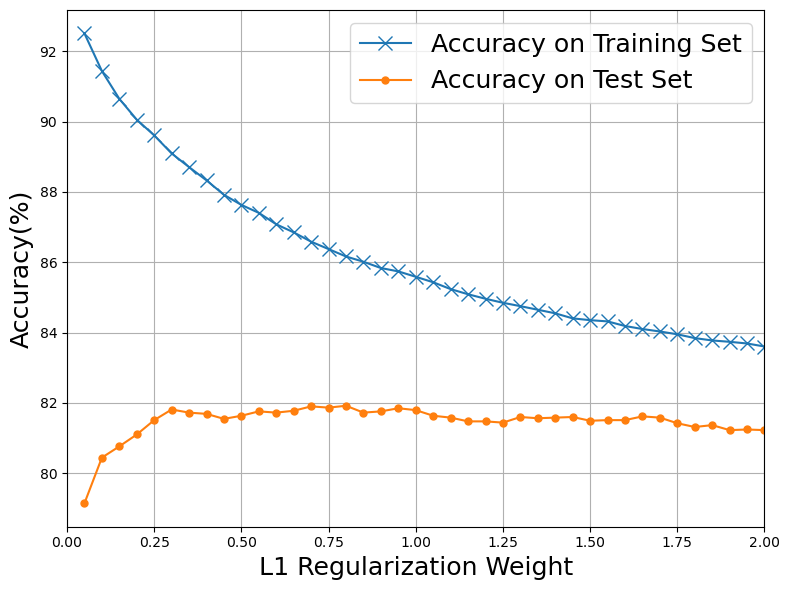

In [17]:
# L1

x = (np.arange(1, 41)/20)
plt.figure(figsize=(8, 6))
plt.grid(True)

plt.plot(x, acc_train_list_l1, label='Accuracy on Training Set', marker='x', markersize=10)
plt.plot(x, acc_test_list_l1, label='Accuracy on Test Set', marker='.', markersize=10)
plt.legend()
plt.xlabel('L1 Regularization Weight', fontsize=10/0.55)
plt.ylabel('Accuracy(%)',  fontsize=10/0.55)
plt.xlim((0, 2))
plt.legend(fontsize= 10/0.55)
plt.tight_layout()

plt.savefig(f'ratio_L1_regularization_regression_3072_weight.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)
plt.show()

## PCA Dimension Reduction

In [46]:
def PCA_dimension_logits(X_train, y_train, X_test, y_test, num=2000):
    # Here the num represents the number of the components remained for each headline
    pca = PCA(n_components=num)
    def pca_fit_transform(X_train, X_test):
        rows_train = X_train.shape[0]
        stacked_data = torch.concat((X_train[:, :3072], X_train[:, 3072:]), axis=0)
        model_pca = pca.fit(stacked_data) 
        stacked_data = model_pca.transform(stacked_data)
        X_train_tmp = torch.concat((torch.Tensor(stacked_data)[:(rows_train), :], torch.Tensor(stacked_data)[(rows_train):, :]), axis=1)
        
        rows_test = X_test.shape[0]
        stacked_test_data = torch.concat((X_test[:, :3072], X_test[:, 3072:]), axis=0)
        stacked_test_data = model_pca.transform(stacked_test_data)
        X_test_tmp = torch.concat((torch.Tensor(stacked_test_data)[:(rows_test), :], torch.Tensor(stacked_test_data)[(rows_test):, :]), axis=1)        
        
        return X_train_tmp, X_test_tmp

    X_train_tmp , X_test_tmp = pca_fit_transform(X_train=X_train, X_test=X_test)

    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Sum_variance:", sum(pca.explained_variance_ratio_))
    
    clf = LogisticRegression(random_state=0, max_iter = 2000).fit(X_train_tmp, y_train)
    accur = clf.score(X_train_tmp, y_train)
    total = len(X_train_tmp)
    print('Accuracy on training data:', accur)
    print('95% CI:', '[', accur-1.96*np.sqrt(accur*(1-accur)/total), 
                                            ',', accur+1.96*np.sqrt(accur*(1-accur)/total),']')
    acc_train = accur
    accur = clf.score(X_test_tmp, y_test)
    total = len(X_test_tmp)
    print('Accuracy on test data:', accur)
    print('95% CI:', '[', accur-1.96*np.sqrt(accur*(1-accur)/total), 
                                            ',', accur+1.96*np.sqrt(accur*(1-accur)/total),']')
    return acc_train, accur


In [47]:
acc_train_list_pca = []
acc_test_list_pca = []

for C in range(1, 23):
    num = 3072 - 128*C
    acc_train, acc_test = PCA_dimension_logits(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, num=num)
    acc_test_list_pca.append(acc_test*100)
    acc_train_list_pca.append(acc_train*100)

Explained variance ratio: [2.37870365e-02 2.06373875e-02 1.91563787e-02 ... 4.97676998e-06
 4.97034919e-06 4.94572221e-06]
Sum_variance: 0.9995186385525799
Accuracy on training data: 0.8615134307407644
95% CI: [ 0.8576895894262915 , 0.8653372720552372 ]
Accuracy on test data: 0.8250355618776671
95% CI: [ 0.8151056671840834 , 0.8349654565712509 ]
Explained variance ratio: [2.37870365e-02 2.06373875e-02 1.91563787e-02 ... 6.42760742e-06
 6.40976143e-06 6.40155236e-06]
Sum_variance: 0.9987917754430046
Accuracy on training data: 0.8615772347348944
95% CI: [ 0.8577541328260794 , 0.8654003366437095 ]
Accuracy on test data: 0.8243243243243243
95% CI: [ 0.8143785571296107 , 0.834270091519038 ]
Explained variance ratio: [2.37870365e-02 2.06373875e-02 1.91563787e-02 ... 7.93410941e-06
 7.92024550e-06 7.90721780e-06]
Sum_variance: 0.9978783608421868
Accuracy on training data: 0.8611306067759842
95% CI: [ 0.8573023347633939 , 0.8649588787885745 ]
Accuracy on test data: 0.8246799431009957
95% CI: [

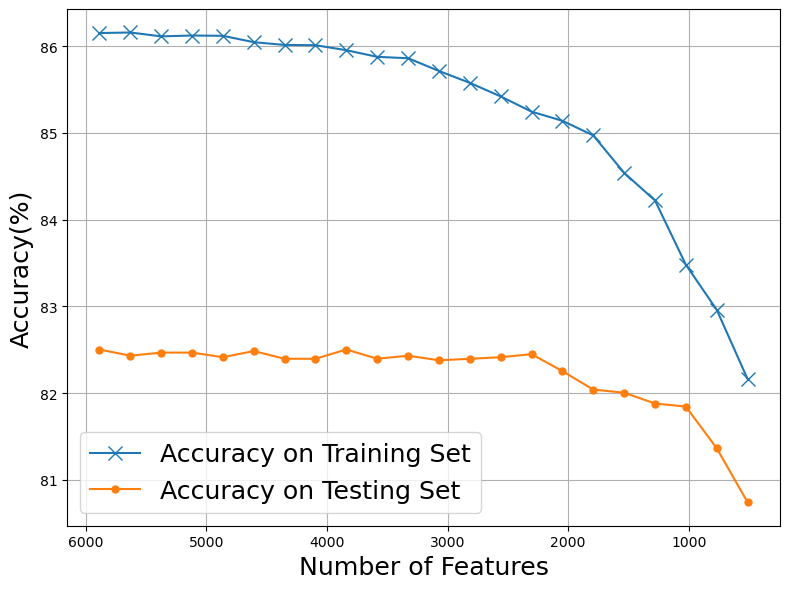

In [48]:
x = 3072 - np.arange(1, 23)*256/2

plt.figure(figsize=(8, 6))
plt.grid(True)

plt.plot(x, acc_train_list_pca, label='Accuracy on Training Set', marker='x', markersize=10)
plt.plot(x, acc_test_list_pca, label='Accuracy on Test Set', marker='.', markersize=10)
plt.gca().invert_xaxis()  # invert the x-axis


plt.xlabel('PCA-reduced Embedding Dimension',  fontsize=10/0.55)
plt.ylabel('Accuracy(%)',  fontsize=10/0.55)
plt.legend(fontsize= 10/0.55)
plt.tight_layout()

# plt.savefig(f'number_of_features_regression_3072.png', format='png', bbox_inches = 'tight', dpi=1200)
plt.savefig(f'number_of_features_regression_3072_pca_both.pdf', format='pdf', bbox_inches = 'tight', dpi=1200)
plt.show()

# Appendix

## Extract GPT embedding (parallel)
---
One can skip the followin code block in this section, because we stored the returned embedding in CSV file.


This code help extract the gpt embedding by parallel requests. But there is a limit by openAI that one account can have maximum 3,000 request per minute. So I keep it to 2,000 requests in this code.

Two parameters regarding embedding:
- DIM, the dimension of embedding
- MODEL, which model to use
---
Reference: https://platform.openai.com/docs/guides/embeddings

In [ ]:
#We provide the code to get embeddings from OpenAI, as well as the returned embedding stored in CSV.

from openai import OpenAI
import concurrent.futures
import time
from threading import Lock
import os

client = OpenAI(api_key='XXX')

DIM = 256
MODEL = "text-embedding-3-large"


# Assuming the DataFrame and other necessary variables are defined
# ...

class RateLimiter:
    def __init__(self, max_requests, per_seconds):
        self.max_requests = max_requests
        self.per_seconds = per_seconds
        self.lock = Lock()
        self.start_time = time.time()
        self.request_count = 0

    def wait(self):
        with self.lock:
            self.request_count += 1
            if self.request_count >= self.max_requests:
                elapsed = time.time() - self.start_time
                if elapsed < self.per_seconds:
                    time.sleep(self.per_seconds - elapsed)
                self.start_time = time.time()
                self.request_count = 0

# Initialize the rate limiter for 2000 requests per minute
rate_limiter = RateLimiter(2000, 60)

def get_embedding(text):
    rate_limiter.wait()
    try:
        response = client.embeddings.create(input=[text], model=MODEL, dimensions=DIM)
        return response.data[0].embedding
    except Exception as e:
        print(f"Error fetching embedding for text: {text}. Error: {e}")
        return None  # Return None if error

def add_embeddings(df, column_name):
    embeddings = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = executor.map(get_embedding, df[column_name])
        embeddings = list(results)

    df[f'embedding_{column_name.split("_")[-1]}'] = embeddings

    
    
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'upworthy-archive-datasets/winner-all.csv')
df = pd.read_csv(file_path)
    
print('getting embeddings for headline 1')
add_embeddings(df, 'headline_1')
print('getting embeddings for headline 2')
add_embeddings(df, 'headline_2')

print('save embeddings')
df.to_csv(f'stored_embeddings_significant/selected_pairs_df_005_{DIM}.csv')

## MLP tuning via Bayesian Optimization

In [ ]:
from skopt import gp_minimize, BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

In [53]:
# Dataset acquisition

df = copy.deepcopy(df_embedding_3072)

random_state = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
train_idx, test_idx = next(gss.split(df, groups=df['test_id']))
train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

# Introducing validation set for early stopping
train_df_1 = train_df.reset_index(drop=True)
gss_train_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=random_state)  # 70: 10: 20
train_idx, val_idx = next(gss_train_val.split(train_df_1, groups=train_df_1['test_id']))
train_df = train_df_1.iloc[train_idx]
val_df = train_df_1.iloc[val_idx]

train_embed_1 = torch.tensor(np.array([eval(s) for s in train_df['embedding_1']])).to(torch.float32)
train_embed_2 = torch.tensor(np.array([eval(s) for s in train_df['embedding_2']])).to(torch.float32)
test_embed_1 = torch.tensor(np.array([eval(s) for s in test_df['embedding_1']])).to(torch.float32)
test_embed_2 = torch.tensor(np.array([eval(s) for s in test_df['embedding_2']])).to(torch.float32)
val_embed_1 = torch.tensor(np.array([eval(s) for s in val_df['embedding_1']])).to(torch.float32)
val_embed_2 = torch.tensor(np.array([eval(s) for s in val_df['embedding_2']])).to(torch.float32)

X_train = torch.cat([train_embed_1, train_embed_2], dim=1)
y_train = torch.tensor(train_df['higher_CTR'].values).to(torch.float32) - 1
X_test = torch.cat([test_embed_1, test_embed_2], dim=1)
y_test = torch.tensor(test_df['higher_CTR'].values).to(torch.float32) - 1
X_val = torch.cat([val_embed_1, val_embed_2], dim=1)
y_val = torch.tensor(val_df['higher_CTR'].values).to(torch.float32) - 1


In [66]:
def prediction_w_NN_hyper_search(X_train, y_train, X_val, y_val, lr=0.01, batch_size=10, EPOCH=1000, early_stopping_rounds=None, tol=None, hidden_size=128, hidden_layer_num=1, dropout_rate=0.5, weight_decay = 0.01, rate=2, DIM=256):    
    net = Net_test(hidden_size=hidden_size, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, rate=rate, DIM=DIM)
    if torch.cuda.is_available():
        net = net.cuda()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)

    trainset = TensorDataset(X_train, y_train)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)  
    
    valset = TensorDataset(X_val, y_val)
    valloader = DataLoader(valset, batch_size=batch_size, shuffle=False)  
    
    acc_history_train = []
    acc_history_val = []
    loss_history_val = []  
    loss_history_train = []  
    best_loss = float('inf')  
    early_stopping_counter = 0  
    print(f'Start Training Neural Network_embedding_3072_hidden_size:{hidden_size}_hidden_layer_num:{hidden_layer_num}_dropout_rate:{dropout_rate}_weight_decay:{weight_decay}_rate:{rate}')
    
    start_time = time.time()
    epoch_1 = 0
    for epoch in range(EPOCH):
        epoch_1 = epoch
        acc_samples = 0
        running_loss = 0.0
        net.train()
        for index, data in enumerate(trainloader, 0):
            inputs, labels = data  
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                labels = labels.cuda()
            optimizer.zero_grad()
            outputs = net(inputs) 
            predicted = torch.round(outputs) 
            acc_samples += (predicted.squeeze() == labels).sum().item()
            loss = criterion(outputs, labels.unsqueeze(1))      
            loss.backward()     
            optimizer.step()                 
            running_loss += loss.item()
        if epoch % (EPOCH // 10) == 0:
            eta = (time.time() - start_time) / (epoch + 1) * (EPOCH - epoch - 1)
            print('[%d] loss: %.3f, eta: %s' % (epoch + 1, running_loss / (index + 1), str(datetime.timedelta(seconds=eta))))
        loss_history_train.append(running_loss / len(trainloader)) 
        acc_history_train.append(acc_samples/y_train.size(0))
        
        # Validation phase
        net.eval()
        acc_samples = 0
        with torch.no_grad():     
            running_loss_val = 0
            for data in valloader:
                inputs, labels = data  
                if torch.cuda.is_available():
                    inputs = inputs.cuda()
                    labels = labels.cuda()
                outputs = net(inputs)
                predicted = torch.round(outputs) 
                acc_samples += (predicted.squeeze() == labels).sum().item()
                loss = criterion(outputs, labels.unsqueeze(1))      
                running_loss_val += loss.item()
            loss_history_val.append(running_loss_val / len(valloader))   
            acc_history_val.append(acc_samples/ y_val.size(0))
            
        if early_stopping_rounds is not None:
            if tol is None:
                tol = np.finfo(np.float32).eps
            if best_loss - loss_history_val[-1] > tol:
                best_loss = loss_history_val[-1]
                early_stopping_counter = 0
                if epoch >= 10:
                    torch.save(net.state_dict(), f'Best_models_for_hyperparameter_search/embedding_3072_NN_{hidden_size}_hidden_layer_num_{hidden_layer_num}_dropout_rate_{dropout_rate}_weight_decay_{weight_decay}_rate_{rate}.pth')
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= early_stopping_rounds:
                    print("Best val_loss at epochs:", epoch-early_stopping_rounds+1)
                    break
                    
    accuracy_val = acc_history_val[epoch_1-early_stopping_rounds]
    accuracy_train = acc_history_train[epoch_1-early_stopping_rounds]
    
    print('val_accuracy:', accuracy_val)
    print('train_accuracy:', accuracy_train)
    print('Finished Training')
    print('Total period: ',time.time()-start_time)
    
    return -accuracy_val 

In [67]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [56]:
space = [Integer(1, 5, name='hidden_layer_num'),
         Categorical(categories=[0.3, 0.5], name='dropout_rate'),
         Categorical(categories=[128, 256, 512, 1024, 2048], name='hidden_size'),
         Categorical(categories=[1e-6, 1e-4, 1e-2], name='weight_decay'),
         Categorical(categories=[2, 4, 8], name='rate')
         ]

In [57]:
dim = 3072
lr=0.01
batch_size=10
EPOCH=1000

In [58]:
# Define directory path and file names for saving individual components with variables included

# directory_path = 'stored_embeddings_significant/train_val_test_split/'
# X_train_data_path = f'{directory_path}X_train_{DIM}_random_state_{random_state}_test_id.pt'
# y_train_data_path = f'{directory_path}y_train_{DIM}_random_state_{random_state}_test_id.pt'
# X_test_data_path = f'{directory_path}X_test_{DIM}_random_state_{random_state}_test_id.pt'
# y_test_data_path = f'{directory_path}y_test_{DIM}_random_state_{random_state}_test_id.pt'
# X_val_data_path = f'{directory_path}X_val_{DIM}_random_state_{random_state}_test_id.pt'
# y_val_data_path = f'{directory_path}y_val_{DIM}_random_state_{random_state}_test_id.pt'

# torch.save(X_train, X_train_data_path)
# torch.save(y_train, y_train_data_path)

# torch.save(X_test, X_test_data_path)
# torch.save(y_test, y_test_data_path)

# torch.save(X_val, X_val_data_path)
# torch.save(y_val, y_val_data_path)


In [59]:
X_test.cuda()
X_train.cuda()
X_val.cuda()
y_test.cuda()
y_train.cuda()
y_val.cuda()

tensor([0., 1., 0.,  ..., 0., 0., 1.], device='cuda:0')

In [68]:
@use_named_args(space)
def objective(hidden_layer_num, dropout_rate, hidden_size, weight_decay, rate):
    return prediction_w_NN_hyper_search(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, hidden_size=hidden_size, lr=lr, batch_size=batch_size, EPOCH=EPOCH, early_stopping_rounds=60, tol=0.0001, weight_decay=weight_decay, rate=rate, DIM=dim)

In [69]:
start=time.time()
res = gp_minimize(objective, space, n_calls=30, random_state=42)  # n_calls: 20~100

print('total_rounds:', time.time()-start)

Start Training Neural Network_embedding_3072_hidden_size:1024_hidden_layer_num:4_dropout_rate:0.3_weight_decay:0.0001_rate:4
[1] loss: 0.693, eta: 2:27:09.262809


KeyboardInterrupt: 

In [ ]:
res.x  # optimized params

In [ ]:
# hidden_layer_num = res.x[0]
# dropout_rate = res.x[1]
# hidden_size = res.x[2]
# weight_decay = res.x[3]
# rate = res.x[4]

hidden_layer_num = 1
dropout_rate = 0.5
hidden_size = 2048
weight_decay = 1e-4
rate = 4


In [ ]:
net_test = Net_test(hidden_size=hidden_size, hidden_layer_num=hidden_layer_num, dropout_rate=dropout_rate, rate=rate)
net_test.load_state_dict(torch.load(f'Best_models_for_hyperparameter_search/embedding_3072_NN_{hidden_size}_hidden_layer_num_{hidden_layer_num}_dropout_rate_{dropout_rate}_weight_decay_{weight_decay}_rate_{rate}.pth'))